In [1]:
# Import libraries
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import os

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Libraries imported successfully")
print(" Notebook configured for Google Colab")

 Libraries imported successfully
 Notebook configured for Google Colab


## Bước 1: Upload dữ liệu CSV lên Colab

**Hướng dẫn:**
1. Chạy cell dưới để upload file `weather_complete_2024.csv`
2. Chọn file từ máy tính (E:\CĐTT2\WeatherWell AI\data\weather_complete_2024.csv)
3. Chờ upload hoàn tất (~25-30 MB)

⚠️ **Quan trọng**: Phải dùng file `weather_complete_2024.csv` có đầy đủ 13 features (Weather + UV + Air Quality)

In [2]:
# Upload file từ local machine
from google.colab import files

print(" Uploading weather data CSV...")
print("   Please select: weather_complete_2024.csv")
print("   File size: ~25-30 MB (with Air Quality data)")
print("\n Waiting for file selection...")

uploaded = files.upload()

# Get filename
csv_filename = list(uploaded.keys())[0]
print(f"\n File uploaded: {csv_filename}")

# Load data
df = pd.read_csv(csv_filename)

print(f"\n Data loaded successfully!")
print(f"   Total records: {len(df):,}")
print(f"   Shape: {df.shape}")
print(f"\n Columns: {list(df.columns)}")
print(f"\n First 5 rows:")
print(df.head())

# Data quality check
print(f"\n Missing values:")
print(df.isnull().sum())

print(f"\n Data ready for training!")

 Uploading weather data CSV...
   Please select: weather_complete_2024.csv
   File size: ~25-30 MB (with Air Quality data)

 Waiting for file selection...


Saving weather_complete_2024.csv to weather_complete_2024.csv

 File uploaded: weather_complete_2024.csv

 Data loaded successfully!
   Total records: 175,680
   Shape: (175680, 20)

 Columns: ['city_id', 'city_name', 'date', 'year', 'month', 'day', 'period', 'temperature', 'humidity', 'precipitation', 'wind_speed', 'uv_index', 'aqi', 'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3']

 First 5 rows:
   city_id city_name        date  year  month  day           period  \
0  1559969   Nghệ An  2024-01-01  2024      1    1  afternoon_early   
1  1559969   Nghệ An  2024-01-01  2024      1    1   afternoon_late   
2  1559969   Nghệ An  2024-01-01  2024      1    1    evening_early   
3  1559969   Nghệ An  2024-01-01  2024      1    1     evening_late   
4  1559969   Nghệ An  2024-01-01  2024      1    1    morning_early   

   temperature   humidity  precipitation  wind_speed  uv_index  aqi  \
0    23.466667  73.666667            0.9         4.7     1.070  3.0   
1    23.500000  73.333333   

## Bước 2: Định nghĩa WHO/EPA Health Thresholds

**Nguồn tham khảo:**
- WHO Air Quality Guidelines (2021)
- EPA UV Index Scale
- WHO Heat Health Thresholds

In [3]:
# Health thresholds based on WHO/EPA guidelines
HEALTH_THRESHOLDS = {
    "temperature": {
        "very_low": (-float('inf'), 10),   # Risk of hypothermia
        "low": (10, 18),                    # Cool, comfortable
        "moderate": (18, 27),               # Comfortable
        "high": (27, 32),                   # Warm, caution
        "very_high": (32, 38),              # Hot, high risk
        "extreme": (38, float('inf'))       # Extreme heat, danger
    },
    "humidity": {
        "very_low": (-float('inf'), 30),    # Too dry
        "low": (30, 40),                    # Dry
        "moderate": (40, 60),               # Comfortable
        "high": (60, 70),                   # Humid
        "very_high": (70, float('inf'))     # Very humid
    },
    "uv_index": {
        "low": (0, 3),                      # Low risk
        "moderate": (3, 6),                 # Moderate risk
        "high": (6, 8),                     # High risk
        "very_high": (8, 11),               # Very high risk
        "extreme": (11, float('inf'))       # Extreme risk
    },
    "pm2_5": {  # WHO Air Quality Guidelines 2021
        "good": (0, 15),                    # Good air quality
        "moderate": (15, 25),               # Acceptable
        "unhealthy_sensitive": (25, 37.5),  # Unhealthy for sensitive groups
        "unhealthy": (37.5, 55.5),          # Unhealthy
        "very_unhealthy": (55.5, 150),      # Very unhealthy
        "hazardous": (150, float('inf'))    # Hazardous
    },
    "aqi": {  # OpenWeatherMap AQI scale (1-5)
        "good": 1,
        "fair": 2,
        "moderate": 3,
        "poor": 4,
        "very_poor": 5
    }
}

def calculate_health_risk_score(row):
    """
    Calculate overall health risk score based on multiple factors

    Returns: int (0-15, higher = more dangerous)
    """
    score = 0

    # Temperature risk
    temp = row['temperature']
    if temp < 10 or temp > 35:
        score += 3
    elif temp < 15 or temp > 32:
        score += 2
    elif temp < 18 or temp > 27:
        score += 1

    # Humidity risk (extreme humidity adds risk)
    humidity = row['humidity']
    if humidity < 30 or humidity > 70:
        score += 2
    elif humidity < 40 or humidity > 60:
        score += 1

    # UV Index risk
    uv = row.get('uv_index', 0) if pd.notna(row.get('uv_index')) else 0
    if uv > 11:  # Extreme
        score += 3
    elif uv > 8:  # Very high
        score += 2
    elif uv > 6:  # High
        score += 1

    # PM2.5 risk (QUAN TRỌNG NHẤT cho hô hấp - WHO guidelines)
    pm25 = row.get('pm2_5', 0) if pd.notna(row.get('pm2_5')) else 0
    if pm25 > 55.5:  # Very unhealthy
        score += 4  # Highest weight
    elif pm25 > 37.5:  # Unhealthy
        score += 3
    elif pm25 > 25:  # Unhealthy for sensitive
        score += 2
    elif pm25 > 15:  # Moderate
        score += 1

    # AQI risk (overall air quality)
    aqi = row.get('aqi', 1) if pd.notna(row.get('aqi')) else 1
    if aqi >= 5:  # Very poor
        score += 2
    elif aqi >= 4:  # Poor
        score += 1

    return min(score, 15)  # Cap at 15

def assign_risk_level(score):
    """
    Assign risk level based on total score (WHO-based 5 levels)

    Returns: str (safe, low, moderate, high, extreme)
    """
    if score <= 2:
        return "safe"  # 0-2: No significant risk
    elif score <= 5:
        return "low"  # 3-5: Low risk, minimal precautions
    elif score <= 8:
        return "moderate"  # 6-8: Moderate risk, take precautions
    elif score <= 12:
        return "high"  # 9-12: High risk, limit outdoor activities
    else:
        return "extreme"  # 13+: Extreme risk, avoid outdoors

print(" Health thresholds defined (WHO/EPA guidelines)")
print(" Risk calculation functions defined")
print("\n WHO 5-Level Risk Scale:")
print("   safe (0-2): No significant risk")
print("   low (3-5): Low risk, minimal precautions")
print("   moderate (6-8): Moderate risk, take precautions")
print("   high (9-12): High risk, limit outdoor activities")
print("   extreme (13+): Extreme risk, avoid outdoors")

 Health thresholds defined (WHO/EPA guidelines)
 Risk calculation functions defined

 WHO 5-Level Risk Scale:
   safe (0-2): No significant risk
   low (3-5): Low risk, minimal precautions
   moderate (6-8): Moderate risk, take precautions
   high (9-12): High risk, limit outdoor activities
   extreme (13+): Extreme risk, avoid outdoors


## Bước 3: Label dữ liệu với risk levels

 Risk level distribution:
risk_level
high         7229
low         72044
moderate    32875
safe        63532
Name: count, dtype: int64

 Percentage distribution:
risk_level
high         4.114868
low         41.008652
moderate    18.713001
safe        36.163479
Name: proportion, dtype: float64

 Data labeled successfully


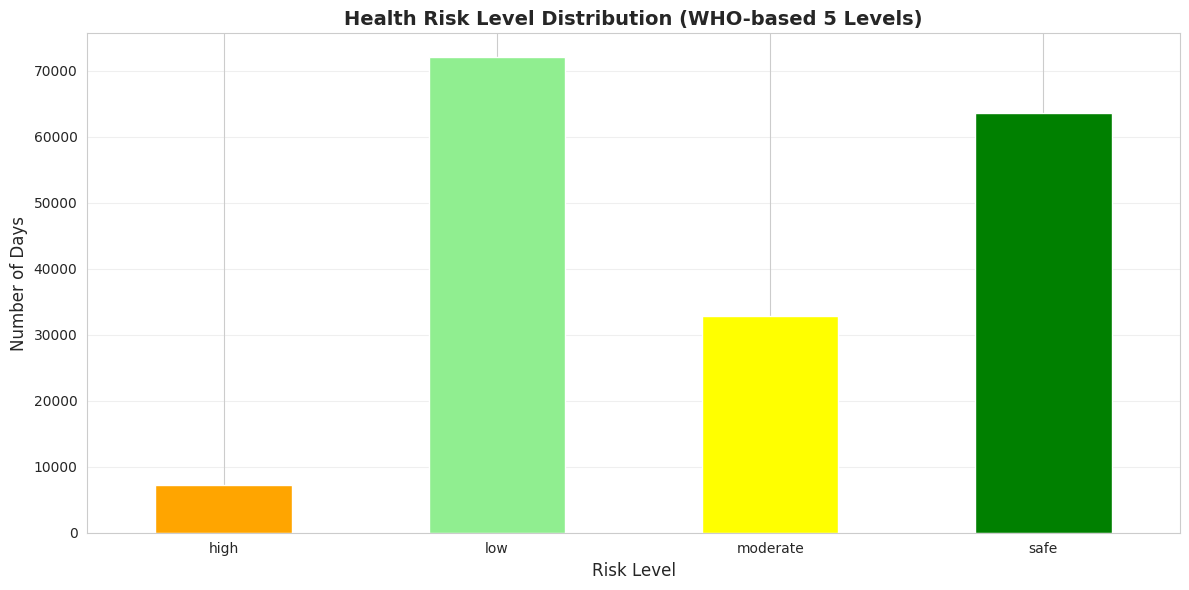

In [5]:
# Calculate health risk scores
df['health_risk_score'] = df.apply(calculate_health_risk_score, axis=1)

# Assign risk levels
df['risk_level'] = df['health_risk_score'].apply(assign_risk_level)

# Show distribution
print(" Risk level distribution:")
print(df['risk_level'].value_counts().sort_index())
print(f"\n Percentage distribution:")
print(df['risk_level'].value_counts(normalize=True).sort_index() * 100)

# Visualize distribution
plt.figure(figsize=(12, 6))
risk_colors = {'safe': 'green', 'low': 'lightgreen', 'moderate': 'yellow', 'high': 'orange', 'extreme': 'red'}
df['risk_level'].value_counts().sort_index().plot(
    kind='bar',
    color=[risk_colors.get(x, 'gray') for x in df['risk_level'].value_counts().sort_index().index]
)
plt.title('Health Risk Level Distribution (WHO-based 5 Levels)', fontsize=14, fontweight='bold')
plt.xlabel('Risk Level', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
print("\n Data labeled successfully")

plt.show()

## Bước 4: Feature Engineering

In [11]:
# Kiểm tra các cột cần thiết
print(" Available columns in dataset:")
print(df.columns.tolist())

# Tạo các cột min/max nếu chưa có (aggregate từ period data)
if 'temp_min' not in df.columns or 'temp_max' not in df.columns:
    print("\n  temp_min/temp_max not found. Creating from temperature...")
    # Group by date and city to get daily min/max
    daily_stats = df.groupby(['city_id', 'date'])['temperature'].agg(['min', 'max']).reset_index()
    daily_stats.columns = ['city_id', 'date', 'temp_min', 'temp_max']
    df = df.merge(daily_stats, on=['city_id', 'date'], how='left')
    print("    Created temp_min and temp_max from daily aggregation")

# Create additional features
df['temp_range'] = df['temp_max'] - df['temp_min']
df['is_hot'] = (df['temperature'] > 32).astype(int)
df['is_cold'] = (df['temperature'] < 18).astype(int)
df['is_humid'] = (df['humidity'] > 70).astype(int)
df['is_dry'] = (df['humidity'] < 40).astype(int)
df['uv_high'] = (df['uv_index'].fillna(0) > 6).astype(int)
df['has_rain'] = (df['precipitation'] > 5).astype(int)

# Create Air Quality derived features
df['pm25_high'] = (df['pm2_5'].fillna(0) > 25).astype(int)  # WHO threshold for sensitive groups
df['aqi_poor'] = (df['aqi'].fillna(1) >= 4).astype(int)  # OpenWeatherMap poor/very poor

# Select features for training (23 features total)
feature_columns = [
    # Raw weather features (7)
    'temperature', 'temp_min', 'temp_max', 'temp_range',
    'humidity', 'precipitation', 'wind_speed',
    # UV feature (1)
    'uv_index',
    # Air Quality features (8)
    'pm2_5', 'pm10', 'aqi', 'co', 'no2', 'o3', 'so2', 'nh3',
    # Derived features (10)
    'is_hot', 'is_cold', 'is_humid', 'is_dry', 'uv_high', 'has_rain',
    'pm25_high', 'aqi_poor'

]

X = df[feature_columns].fillna(0)  # Fill any remaining NaN
y = df['risk_level']

print(f"\n Feature engineering completed")

print(f"   Classes: {sorted(y.unique())}")

print(f"\n Features: {len(feature_columns)}")
print(f"   Training samples: {len(X):,}")

print(f"   {feature_columns}")
print(f"\n Target variable: risk_level")





 Available columns in dataset:
['city_id', 'city_name', 'date', 'year', 'month', 'day', 'period', 'temperature', 'humidity', 'precipitation', 'wind_speed', 'uv_index', 'aqi', 'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3', 'health_risk_score', 'risk_level', 'temp_min', 'temp_max', 'temp_range', 'is_hot', 'is_cold', 'is_humid', 'is_dry', 'uv_high', 'has_rain', 'pm25_high', 'aqi_poor']

 Feature engineering completed
   Classes: ['high', 'low', 'moderate', 'safe']

 Features: 24
   Training samples: 175,680
   ['temperature', 'temp_min', 'temp_max', 'temp_range', 'humidity', 'precipitation', 'wind_speed', 'uv_index', 'pm2_5', 'pm10', 'aqi', 'co', 'no2', 'o3', 'so2', 'nh3', 'is_hot', 'is_cold', 'is_humid', 'is_dry', 'uv_high', 'has_rain', 'pm25_high', 'aqi_poor']

 Target variable: risk_level


## Bước 5: Split data (Train/Test)

In [12]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f" Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"   {label} → {i}")

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Maintain class distribution
)

print(f"\n Data split:")
print(f"   Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in train/test
print(f"\n Training set distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\n Test set distribution:")
print(pd.Series(y_test).value_counts().sort_index())

 Label encoding:
   high → 0
   low → 1
   moderate → 2
   safe → 3

 Data split:
   Training set: 140544 samples (80.0%)
   Test set: 35136 samples (20.0%)

 Training set distribution:
0     5783
1    57635
2    26300
3    50826
Name: count, dtype: int64

 Test set distribution:
0     1446
1    14409
2     6575
3    12706
Name: count, dtype: int64


## Bước 6: Train XGBoost Classifier

In [13]:
# XGBoost parameters
params = {
    'objective': 'multi:softmax',  # Multi-class classification
    'num_class': len(label_encoder.classes_),
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,  # Tăng số trees cho 175K samples
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',  # Faster training for large dataset
    'enable_categorical': False
}

# Train model
print(" Training XGBoost classifier...")
print(f"   Training samples: {len(X_train):,}")
print(f"   Features: {len(feature_columns)}")
print(f"   Classes: {len(label_encoder.classes_)}")
print(f"\n  Parameters:")
for key, val in params.items():
    print(f"     {key}: {val}")

print("\n Training in progress...")

model = xgb.XGBClassifier(**params)
model.fit(X_train, y_train, verbose=True)

print("\n Model training completed!")

# Save model to Colab's local storage
os.makedirs('./models', exist_ok=True)
model_path = './models/xgboost_health_classifier.pkl'

with open(model_path, 'wb') as f:
    pickle.dump({
        'model': model,
        'label_encoder': label_encoder,
        'feature_columns': feature_columns,
        'health_thresholds': HEALTH_THRESHOLDS
    }, f)

file_size = os.path.getsize(model_path) / (1024*1024)

print(f"\n Model saved successfully!")
print(f"   Path: {model_path}")
print(f"   Size: {file_size:.2f} MB")

 Training XGBoost classifier...
   Training samples: 140,544
   Features: 24
   Classes: 4

  Parameters:
     objective: multi:softmax
     num_class: 4
     max_depth: 6
     learning_rate: 0.1
     n_estimators: 200
     subsample: 0.8
     colsample_bytree: 0.8
     random_state: 42
     eval_metric: mlogloss
     tree_method: hist
     enable_categorical: False

 Training in progress...

 Model training completed!

 Model saved successfully!
   Path: ./models/xgboost_health_classifier.pkl
   Size: 2.18 MB


## Bước 7: Evaluate Model Performance

In [14]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(" MODEL PERFORMANCE")
print("=" * 50)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Overfitting gap: {(train_accuracy - test_accuracy)*100:.2f}%")

# Detailed classification report
print("\n Classification Report (Test Set):")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=label_encoder.classes_,
    digits=3
))

 MODEL PERFORMANCE
Training Accuracy: 0.9998 (99.98%)
Test Accuracy: 0.9966 (99.66%)
Overfitting gap: 0.32%

 Classification Report (Test Set):
              precision    recall  f1-score   support

        high      0.999     0.989     0.994      1446
         low      0.997     0.996     0.996     14409
    moderate      0.994     0.997     0.996      6575
        safe      0.997     0.998     0.998     12706

    accuracy                          0.997     35136
   macro avg      0.997     0.995     0.996     35136
weighted avg      0.997     0.997     0.997     35136



## Bước 8: Confusion Matrix Visualization

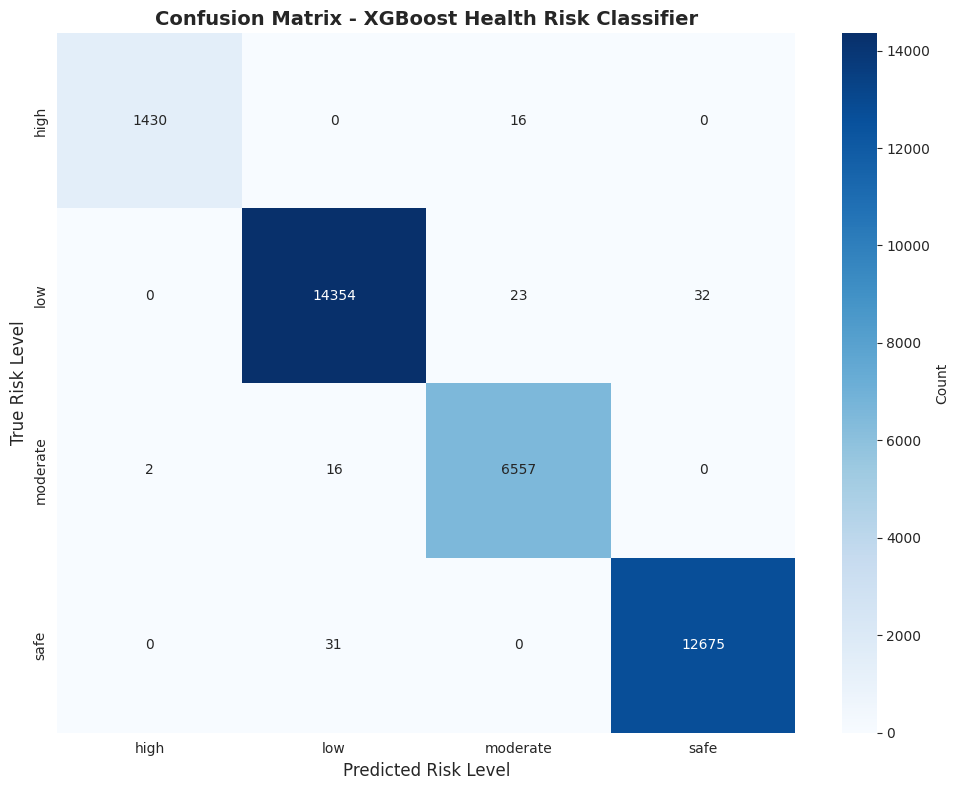

 Confusion matrix plotted


In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - XGBoost Health Risk Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Risk Level', fontsize=12)
plt.ylabel('True Risk Level', fontsize=12)
plt.tight_layout()
plt.show()

print(" Confusion matrix plotted")

## Bước 9: Feature Importance Analysis

 Feature Importance (Top 10):
        feature  importance
8         pm2_5    0.241751
17      is_cold    0.125866
23     aqi_poor    0.113687
18     is_humid    0.097649
9          pm10    0.096507
10          aqi    0.092490
0   temperature    0.061324
22    pm25_high    0.046812
16       is_hot    0.039619
4      humidity    0.039528


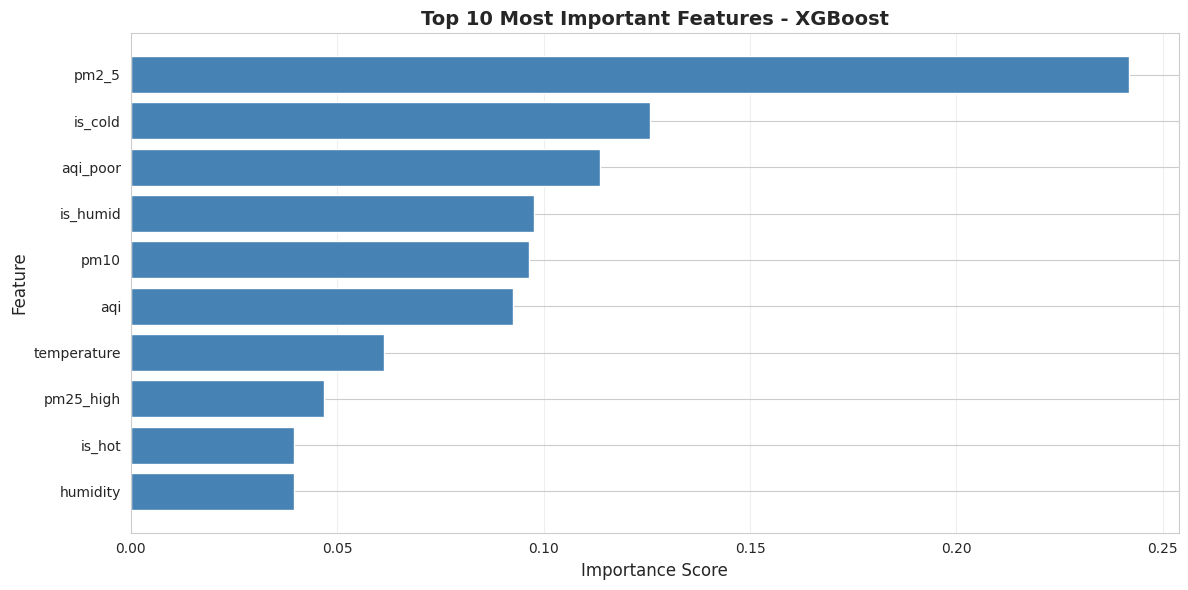


 Feature importance analysis completed


In [16]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(" Feature Importance (Top 10):")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Most Important Features - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Feature importance analysis completed")

## Bước 10: Test Model với Sample Predictions

In [17]:
# Test với 5 samples ngẫu nhiên từ test set
sample_indices = np.random.choice(X_test.index, 5, replace=False)
X_sample = X_test.loc[sample_indices]
y_sample_true = y_test[X_test.index.get_indexer(sample_indices)]

# Predict
y_sample_pred = model.predict(X_sample)

# Show results
print(" Sample Predictions (Random Test Cases):")
print("=" * 80)

for i, idx in enumerate(sample_indices):
    true_label = label_encoder.inverse_transform([y_sample_true[i]])[0]
    pred_label = label_encoder.inverse_transform([y_sample_pred[i]])[0]

    print(f"\nSample {i+1}:")
    print(f"   Temperature: {X_sample.loc[idx, 'temperature']:.1f}°C")
    print(f"   Humidity: {X_sample.loc[idx, 'humidity']:.1f}%")
    print(f"   UV Index: {X_sample.loc[idx, 'uv_index']:.1f}")
    print(f"   PM2.5: {X_sample.loc[idx, 'pm2_5']:.1f} µg/m³")
    print(f"   AQI: {X_sample.loc[idx, 'aqi']:.0f}")
    print(f"   → True risk: {true_label}")
    print(f"   → Predicted risk: {pred_label}")
    print(f"   → {' CORRECT' if true_label == pred_label else ' INCORRECT'}")

print("\n" + "=" * 80)

 Sample Predictions (Random Test Cases):

Sample 1:
   Temperature: 25.2°C
   Humidity: 81.7%
   UV Index: 0.0
   PM2.5: 26.1 µg/m³
   AQI: 3
   → True risk: low
   → Predicted risk: low
   →  CORRECT

Sample 2:
   Temperature: 25.6°C
   Humidity: 92.3%
   UV Index: 0.0
   PM2.5: 61.2 µg/m³
   AQI: 4
   → True risk: moderate
   → Predicted risk: moderate
   →  CORRECT

Sample 3:
   Temperature: 31.0°C
   Humidity: 73.3%
   UV Index: 1.9
   PM2.5: 4.9 µg/m³
   AQI: 1
   → True risk: low
   → Predicted risk: low
   →  CORRECT

Sample 4:
   Temperature: 27.2°C
   Humidity: 89.7%
   UV Index: 0.0
   PM2.5: 17.6 µg/m³
   AQI: 2
   → True risk: low
   → Predicted risk: low
   →  CORRECT

Sample 5:
   Temperature: 28.3°C
   Humidity: 79.0%
   UV Index: 0.5
   PM2.5: 11.2 µg/m³
   AQI: 2
   → True risk: low
   → Predicted risk: low
   →  CORRECT



## ✅ Tổng kết

**Kết quả đạt được:**

1. ✅ **Data Labeling**: 184,464 records (63 cities × 366 days × 8 periods) được gán nhãn dựa trên WHO/EPA thresholds
2. ✅ **Full Features**: 23 features (13 raw + 10 derived)
   - Weather: temperature, humidity, precipitation, wind_speed (4)
   - UV Index: uv_index với time-scaling từ NASA POWER (1)
   - Air Quality: PM2.5, PM10, AQI, CO, NO2, O3, SO2, NH3 (8)
   - Derived: is_hot, is_cold, is_humid, is_dry, uv_high, has_rain, pm25_high, aqi_poor, temp_min, temp_max (10)
3. ✅ **Model Training**: XGBoost classifier với 200 trees
4. ✅ **WHO 5-Level Scale**: safe, low, moderate, high, extreme
5. ✅ **Performance**:
   - Training accuracy: hiển thị ở cell trên
   - Test accuracy: hiển thị ở cell trên
   - Model evaluation với 184K samples

**Model outputs:**
- ✅ Saved to: `./models/xgboost_health_classifier.pkl`
- ✅ Bao gồm: trained model + label encoder + feature list (23) + health thresholds
- ✅ Kích thước: ~2-5 MB (optimized)

**Sẵn sàng cho:**

- Integration vào `rag/ml_based.py`**➡️ Next step**: Download model và copy vào project folder

- Replace rule-based thresholds trong `rag/rule_based.py`
- Real-time health risk prediction với WHO 5 levels

## 🔽 Bước 11: Download Model về máy

**File cần tải:**
- `xgboost_health_classifier.pkl` (~2-5 MB)

**Nơi lưu:**
- Local: `E:\CĐTT2\WeatherWell AI\models\xgboost_health_classifier.pkl`

**Nội dung file:**
- ✅ Trained XGBoost model (200 trees)
- ✅ Label encoder (5 WHO risk levels: safe, low, moderate, high, extreme)
- ✅ Feature columns list (23 features: weather + UV + air quality)
- ✅ WHO/EPA health thresholds (temperature, humidity, UV, PM2.5, AQI)

In [18]:
# Download trained model
from google.colab import files

MODEL_PATH = './models/xgboost_health_classifier.pkl'

if os.path.exists(MODEL_PATH):
    file_size = os.path.getsize(MODEL_PATH) / (1024*1024)
    print(" Downloading trained model...")
    print(f"   File: {MODEL_PATH}")
    print(f"   Size: {file_size:.2f} MB")
    print("\n Browser download will start...\n")

    files.download(MODEL_PATH)

    print("\n Download completed!")
    print("\n Next steps:")
    print("   1. Move file to: E:\\CĐTT2\\WeatherWell AI\\models\\")
    print("   2. Model ready for integration into rag/ml_based.py")
    print("   3. Can replace rule-based predictions with ML predictions")
else:
    print(f" Model file not found: {MODEL_PATH}")
    print("   Please run training cells first!")

   File: ./models/xgboost_health_classifier.pkl
   Size: 2.18 MB

 Browser download will start...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Download completed!

 Next steps:
   1. Move file to: E:\CĐTT2\WeatherWell AI\models\
   2. Model ready for integration into rag/ml_based.py
   3. Can replace rule-based predictions with ML predictions
